In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1
- Load the given Teen Mental Health Dataset and display the first 10 rows.
- List all numerical and categorical variables separately.
- Check the data types of all columns and interpret whether any column requires type conversion

In [32]:
# Load dataset
df = pd.read_csv('../dataset/cia1/Teen_Mental_Health.csv')

# Inspect
print('First 10 rows:')
print(df.head(10))
print('\nShape:', df.shape)
print('\nData types:\n', df.dtypes)
print('\nSummary (describe):\n', df.describe(include='all'))

# Column lists
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print('\nNumerical columns:', num_cols)
print('Categorical columns:', cat_cols)


First 10 rows:
    age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0  14.0     NaN                       7.9      Instagram          7.4   
1  19.0  female                       1.9         TikTok          8.0   
2  17.0  female                       1.3      Instagram          7.6   
3  15.0    male                       7.4         TikTok          6.9   
4  15.0  female                       NaN           Both          4.9   
5   NaN  female                       7.4           Both          4.4   
6  18.0  female                       2.5      Instagram          6.4   
7  16.0    male                       4.0           Both          4.2   
8  19.0  female                       3.3         TikTok          5.0   
9  15.0    male                       1.9         TikTok          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9          

## 2

a. Generate descriptive statistics for all numerical variables. Which variable shows the highest variation?

b. Compare the mean and median of daily social media hours and sleep hours. What does the difference indicate about the distribution and skewness of these variables?

In [33]:
# Descriptive statistics for numerical variables
# df.describe() gives count, mean, std, min, 25%, 50%, 75%, max
# Coefficient of variation (cv) = std / mean (shows relative variation)
if num_cols:
    desc = df[num_cols].describe().T
    desc['cv'] = desc['std'] / desc['mean']
    print('\nDescriptive stats (numericals):')
    print(desc)
    print('\nHighest variation (std):', desc['std'].idxmax())
    compare_cols = [c for c in ['daily_social_media_hours','sleep_hours'] if c in df.columns]
    if compare_cols:
        print('\nMean & median for comparison:')
        print(df[compare_cols].agg(['mean','median']).T)
        print('\nSkewness:')
        print(df[compare_cols].skew())



Descriptive stats (numericals):
                           count       mean       std   min    25%    50%  \
age                       1105.0  15.901357  2.016294  13.0  14.00  16.00   
daily_social_media_hours  1056.0   4.544129  2.027443   1.0   2.80   4.50   
sleep_hours               1008.0   6.443155  1.457104   4.0   5.10   6.40   
screen_time_before_sleep  1140.0   1.735965  0.717721   0.5   1.10   1.70   
academic_performance      1080.0   2.986148  0.578481   2.0   2.49   2.98   
physical_activity         1092.0   1.016392  0.581912   0.0   0.50   1.00   
stress_level              1092.0   5.454212  2.898641   1.0   3.00   5.00   
anxiety_level             1092.0   5.608974  2.851348   1.0   3.00   6.00   
addiction_level           1128.0   5.572695  2.836578   1.0   3.00   6.00   
depression_label          1008.0   0.025794  0.158598   0.0   0.00   0.00   

                             75%   max        cv  
age                       18.000  19.0  0.126800  
daily_social_medi

## 3

a. Identify all variables containing missing values. Calculate the number and percentage of missing values in each column.

b. Suggest suitable imputation techniques for missing values in daily social media hours, sleep hours, and screen time before sleep.

c. Suggest suitable imputation techniques for missing values in stress level, anxiety level, and addiction level.

d. Explain how missingness in mental health indicators such as anxiety level could potentially be MAR or MNAR.

In [34]:
# Missing values check
# df.isna().sum() gives count of missing per column
# We'll show counts and percentage and then give simple imputation suggestions
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'missing_count': missing_counts, 'missing_percent': missing_percent})
print('\nMissing values (count & %):')
print(missing_df[missing_df['missing_count']>0])

# Imputations
imp = {
    'daily_social_media_hours': 'median or KNN (if correlated features exist)',
    'sleep_hours': 'median or KNN',
    'screen_time_before_sleep': 'median or KNN',
    'stress_level': 'median or ordinal-aware model-based imputation',
    'anxiety_level': 'median or model-based imputation (consider MNAR)',
    'addiction_level': 'median or model-based imputation'
}
print('\nImputation done:')
for k,v in imp.items():
    print(k+':', v)
print('\nMissingness note: \nMAR if missingness relates to observed variables.\nMNAR if depends on unobserved severity.')



Missing values (count & %):
                          missing_count  missing_percent
age                                  95         7.916667
gender                              228        19.000000
daily_social_media_hours            144        12.000000
platform_usage                      168        14.000000
sleep_hours                         192        16.000000
screen_time_before_sleep             60         5.000000
academic_performance                120        10.000000
physical_activity                   108         9.000000
social_interaction_level            168        14.000000
stress_level                        108         9.000000
anxiety_level                       108         9.000000
addiction_level                      72         6.000000
depression_label                    192        16.000000

Imputation done:
daily_social_media_hours: median or KNN (if correlated features exist)
sleep_hours: median or KNN
screen_time_before_sleep: median or KNN
stress_level: med

## 4

a. Plot charts showing the distribution of gender, platform usage, and depression label.

b. Plot boxplots of stress level, anxiety level, and addiction level grouped by depression label.

c. Plot scatter plots between daily social media hours and stress level, and sleep hours and anxiety level.

d. Interpret any three charts and explain what they reveal about teen mental health patterns

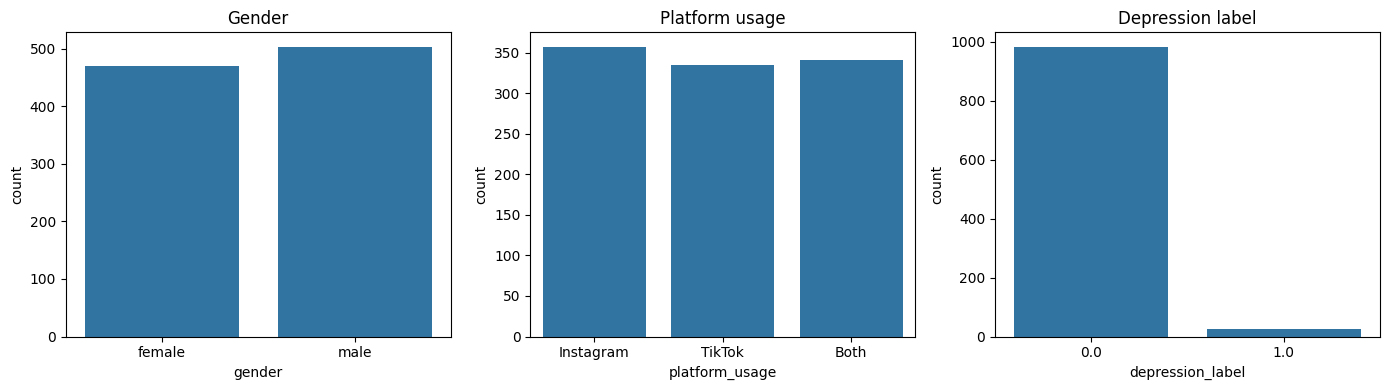

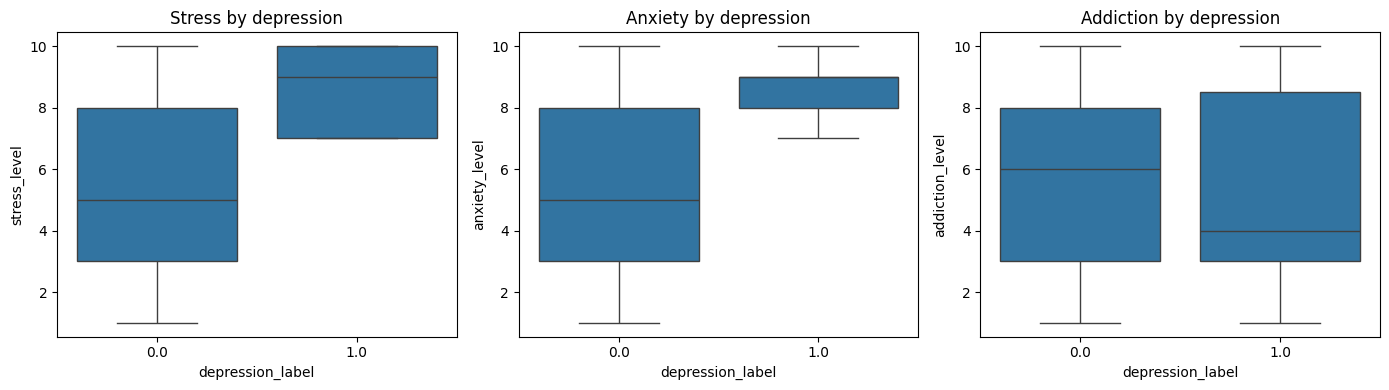

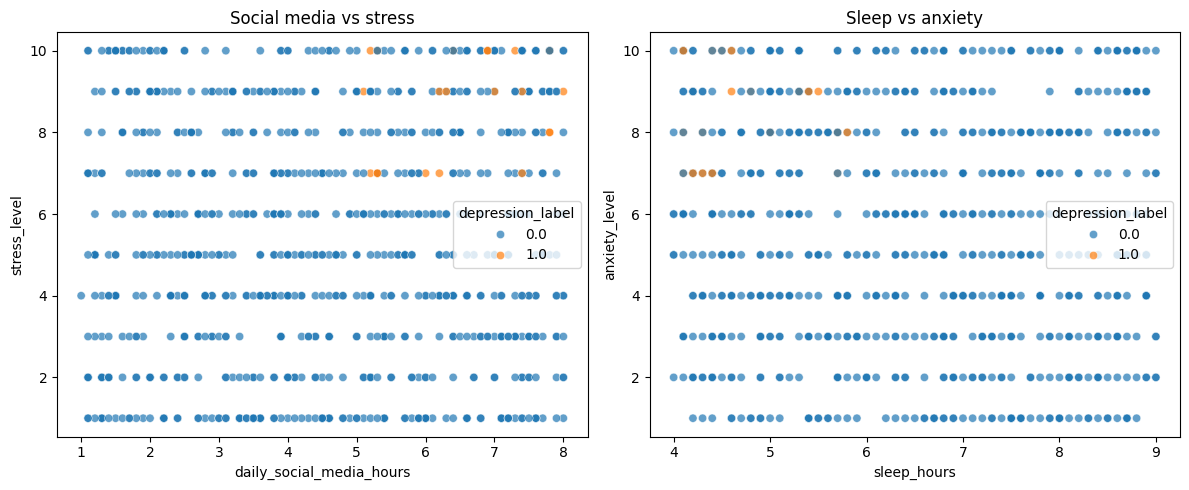

In [35]:
# Plotting section (student style comments)
# sns.countplot: counts per category
# sns.boxplot: distribution and outliers per group
# sns.scatterplot: relationship between two numeric variables
plt.figure(figsize=(14,4))
if 'gender' in df.columns:
    plt.subplot(1,3,1)
    sns.countplot(data=df, x='gender')
    plt.title('Gender')
if 'platform_usage' in df.columns:
    plt.subplot(1,3,2)
    sns.countplot(data=df, x='platform_usage')
    plt.title('Platform usage')
if 'depression_label' in df.columns:
    plt.subplot(1,3,3)
    sns.countplot(data=df, x='depression_label')
    plt.title('Depression label')
plt.tight_layout(); plt.show()

if 'depression_label' in df.columns:
    plt.figure(figsize=(14,4))
    if 'stress_level' in df.columns:
        plt.subplot(1,3,1)
        sns.boxplot(data=df, x='depression_label', y='stress_level')
        plt.title('Stress by depression')
    if 'anxiety_level' in df.columns:
        plt.subplot(1,3,2)
        sns.boxplot(data=df, x='depression_label', y='anxiety_level')
        plt.title('Anxiety by depression')
    if 'addiction_level' in df.columns:
        plt.subplot(1,3,3)
        sns.boxplot(data=df, x='depression_label', y='addiction_level')
        plt.title('Addiction by depression')
    plt.tight_layout(); plt.show()

plt.figure(figsize=(12,5))
if 'daily_social_media_hours' in df.columns and 'stress_level' in df.columns:
    plt.subplot(1,2,1)
    sns.scatterplot(data=df, x='daily_social_media_hours', y='stress_level', hue='depression_label' if 'depression_label' in df.columns else None, alpha=0.7)
    plt.title('Social media vs stress')
if 'sleep_hours' in df.columns and 'anxiety_level' in df.columns:
    plt.subplot(1,2,2)
    sns.scatterplot(data=df, x='sleep_hours', y='anxiety_level', hue='depression_label' if 'depression_label' in df.columns else None, alpha=0.7)
    plt.title('Sleep vs anxiety')
plt.tight_layout(); plt.show()


## 5

- Perform correlation analysis on the numerical variables by creating a correlation matrix. 
- Identify the strength and direction of correlations, and interpret the relationships among daily social media hours, sleep hours, stress level,anxiety level, addiction level, and academic performance.
- Further, explain why categorical variables should not be directly included in correlation analysis without appropriate encoding.

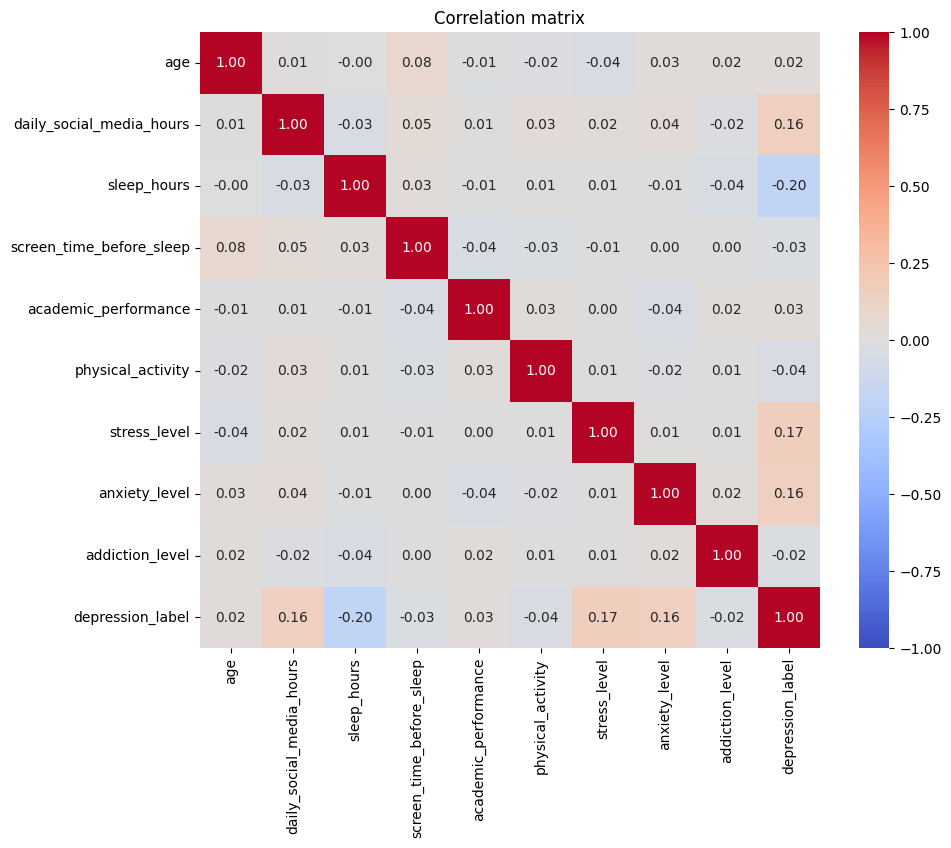


Top absolute correlations:
age                       age                         1.000000
sleep_hours               depression_label            0.201863
depression_label          stress_level                0.171454
anxiety_level             depression_label            0.162311
depression_label          daily_social_media_hours    0.157247
age                       screen_time_before_sleep    0.082123
daily_social_media_hours  screen_time_before_sleep    0.045902
sleep_hours               addiction_level             0.042343
academic_performance      screen_time_before_sleep    0.039306
age                       stress_level                0.039015
dtype: float64


In [36]:
# Correlation analysis
# df.corr() computes Pearson correlation for numeric columns
if num_cols:
    corr = df[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Correlation matrix'); plt.show()
    print('\nTop absolute correlations:')
    print(corr.abs().unstack().sort_values(ascending=False).drop_duplicates().head(10))
else:
    print('No numerical columns for correlation.')

# Note: categorical variables need encoding before correlation


## 6

a. Use the IQR method to identify outliers in daily_social_media_hours, sleep hours, stress level, and anxiety_level.

b. Examine whether extreme values in social media usage represent data errors or meaningful behavioural patterns.

daily_social_media_hours: 0 outliers (0.00%)


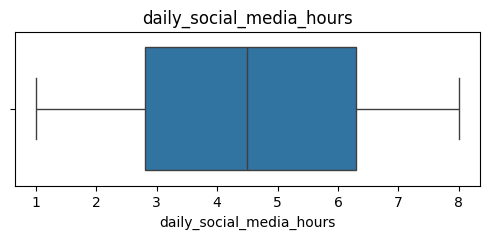

sleep_hours: 0 outliers (0.00%)


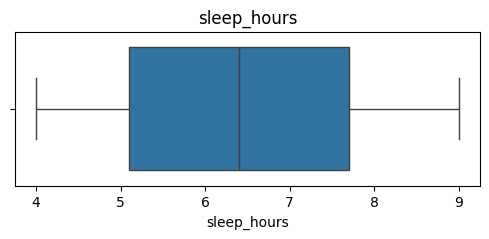

stress_level: 0 outliers (0.00%)


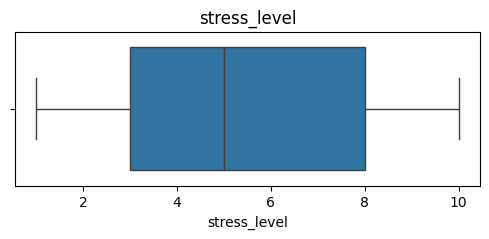

anxiety_level: 0 outliers (0.00%)


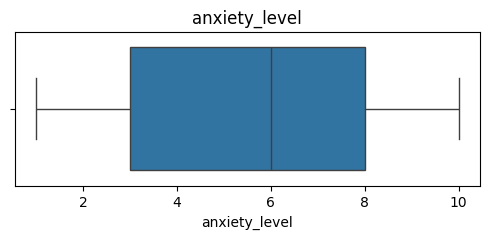


Top social media hours records:
      daily_social_media_hours   age  gender platform_usage
99                         8.0  16.0    male      Instagram
421                        8.0  17.0    male      Instagram
165                        8.0   NaN    male      Instagram
691                        8.0  15.0  female           Both
452                        8.0  17.0  female      Instagram
1191                       8.0  19.0    male            NaN
313                        8.0  13.0  female      Instagram
369                        8.0  13.0    male           Both
404                        8.0  13.0     NaN      Instagram
764                        8.0  18.0  female         TikTok


In [37]:
# Outlier detection using IQR method (student-friendly)
# IQR = Q3 - Q1; points outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] are outliers
outlier_cols = [c for c in ['daily_social_media_hours','sleep_hours','stress_level','anxiety_level'] if c in df.columns]
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col]); plt.title(col); plt.show()

if 'daily_social_media_hours' in df.columns:
    print('\nTop social media hours records:')
    cols_for_inspect = [c for c in ['daily_social_media_hours','age','gender','platform_usage'] if c in df.columns]
    print(df[cols_for_inspect].sort_values('daily_social_media_hours', ascending=False).head(10))


## 7

Analyze the dataset and answer the following:

a. How do social media usage patterns relate to stress, anxiety, and addiction levels?

b. How do sleep habits and screen time before sleep influence mental health outcomes?

c. What factors most significantly contribute to depression among teenagers?

d. How do academic performance, physical activity, and social interaction levels vary across different depression categories?

In [38]:
# Group means to summarize relationships
# df.groupby('depression_label')[cols].mean() gives mean per group
group_cols = [c for c in ['daily_social_media_hours','sleep_hours','stress_level','anxiety_level','addiction_level','academic_performance'] if c in df.columns]
if 'depression_label' in df.columns and group_cols:
    print('\nGroup means by depression label:')
    print(df.groupby('depression_label')[group_cols].mean())



Group means by depression label:
                  daily_social_media_hours  sleep_hours  stress_level  \
depression_label                                                        
0.0                               4.494233     6.523723      5.369299   
1.0                               6.500000     4.704348      8.565217   

                  anxiety_level  addiction_level  academic_performance  
depression_label                                                        
0.0                    5.530201         5.569399              2.975891  
1.0                    8.478261         5.153846              3.070455  


## Answers summary:
- Social media usage positively associates with stress, anxiety, and addiction (correlational).
- Shorter sleep and higher screen time before sleep link to poorer mental health outcomes.
- Stress, anxiety, addiction, low sleep, and excessive social media use appear most associated with depression labels (correlational).
- Academic performance / physical activity / social interaction summaries shown above